# Premier notebook · Le fichier de Comtoise Auto Occasion

**ELC2 · Introduction au machine learning · Séance 1**

[![Ouvrir dans Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josephazar/ELC2-Introduction-IA-2026/blob/main/seance-1/ia-elc2/01-premier-notebook.ipynb)

Vous allez refaire en Python ce que nous avons fait en cours sur le fichier de Nathalie.
Vous n'avez **rien à écrire** : il suffit d'exécuter les cellules.

**Comment ça marche.** Cliquez dans une cellule grise, puis appuyez sur **Maj + Entrée**.
Le résultat s'affiche juste en dessous. Faites-le pour chaque cellule, **dans l'ordre**,
de haut en bas.

Si quelque chose part de travers : menu **Run → Run All Cells** dans Jupyter, ou
**Exécution → Tout exécuter** sur Google Colab. Tout recommence depuis le fichier Excel, qui,
lui, n'est jamais modifié.

## 0. Vérifier que tout est prêt

Cette cellule dit où tourne votre notebook. Sur votre ordinateur, ce doit être le Python du
dossier `.venv` de votre dossier `ia-elc2`, et pas celui de votre système. Sur Google Colab,
il n'y a rien à vérifier.

In [1]:
import sys
from pathlib import Path

python_utilise = Path(sys.executable)

if "google.colab" in sys.modules:
    print("OK : vous êtes sur Google Colab, il n'y a rien à installer.")
elif ".venv" in python_utilise.parts:
    print("Python utilisé :", ".../" + "/".join(python_utilise.parts[-4:]))
    print("OK : ce notebook tourne dans l'environnement virtuel du cours.")
else:
    print("Python utilisé :", python_utilise)
    print("ATTENTION : ce n'est pas le Python du cours. Relisez le guide d'installation.")

Python utilisé : .../ia-elc2/.venv/bin/python
OK : ce notebook tourne dans l'environnement virtuel du cours.


Le fichier de Nathalie est-il là ? Sur votre ordinateur, il est dans le dossier `donnees`.
Sur Google Colab, cette cellule le télécharge depuis la page GitHub du cours.

In [2]:
from urllib.request import urlretrieve

fichier = Path("donnees/ventes-3-agences.xlsx")
if not fichier.exists():
    fichier.parent.mkdir(exist_ok=True)
    urlretrieve("https://raw.githubusercontent.com/josephazar/ELC2-Introduction-IA-2026/main/"
                "seance-1/ia-elc2/donnees/ventes-3-agences.xlsx", fichier)
    print("Fichier téléchargé depuis GitHub.")

print("Données prêtes :", fichier)

Données prêtes : donnees/ventes-3-agences.xlsx


## 1. Regarder avant de toucher

`pandas` est la bibliothèque qui manipule des tableaux. On la charge sous le petit nom `pd`,
puis on ouvre le fichier de Nathalie. Le tableau s'appelle désormais `ventes`.

In [3]:
import pandas as pd

ventes = pd.read_excel("donnees/ventes-3-agences.xlsx")
ventes.head(20)

,ref,agence,marque,modele,annee,kilometrage,carburant,etat,remise,prix
0,V-0001,Montbéliard,Peugeot,308,2021,96570,Diesel,Bon,5.0,13400
1,V-0002,Montbeliard,Dacia,Duster,2022,30159,Diesel,Très bon,7.0,12400
2,V-0003,Belfort,Citroën,C4,2013,145 395 km,Essence,Correct,6.4,3400
3,V-0004,Montbéliard,Peugeot,308,2013,245277,Gazole,Mauvais,5.6,2500
4,V-0005,Besançon,Citroën,C3,2018,201541,Diesel,Correct,6.9,NaN
5,V-0006,Belfort,Dacia,Sandero,2024,15401,Essence,Tres bon,6.0,11000
6,V-0007,Montbéliard,Renault,Clio,2015,169600,essence,Correct,4.0,3100
7,V-0008,Besançon,Volkswagen,Golf,2018,80874,Hybride,Bon,5.3,9 000 €
8,V-0009,Besançon,Toyota,Yaris,2031,24800,Hybride,Très bon,6.2,11200
9,V-0010,Belfort,Citroën,C4,2021,NaN,Diesel,Bon,8.0,12800


Ce sont les 20 lignes de l'extrait imprimé dans le mail. Attention : Python compte à partir
de **0**, donc la ligne 1 du mail est la ligne `0` ici.

Les cases vides s'affichent `NaN` : c'est la façon qu'a Python d'écrire « rien ».

Combien de lignes et de colonnes en tout ?

In [4]:
ventes.shape

(146, 10)

## 2. Les doublons

Combien de lignes sont la copie exacte d'une ligne déjà vue ?

In [5]:
print("Doublons :", ventes.duplicated().sum())

Doublons : 6


La vente `V-0004`, par exemple, apparaît deux fois :

In [6]:
ventes[ventes["ref"] == "V-0004"]

,ref,agence,marque,modele,annee,kilometrage,carburant,etat,remise,prix
3,V-0004,Montbéliard,Peugeot,308,2013,245277,Gazole,Mauvais,5.6,2500
12,V-0004,Montbéliard,Peugeot,308,2013,245277,Gazole,Mauvais,5.6,2500


On garde un seul exemplaire de chaque ligne, puis on recompte.

In [7]:
ventes = ventes.drop_duplicates()
len(ventes)

140

## 3. Le texte qui dit la même chose

Combien d'écritures différentes pour nos trois agences ?

In [8]:
ventes["agence"].value_counts()

agence
Montbéliard     44
Besançon        42
Belfort         40
Montbeliard      4
Besancon         3
Belfort          3
besançon         2
Montbéliard      1
MONTBELIARD      1
Name: count, dtype: int64

Deux lignes semblent identiques. Affichons chaque écriture entre guillemets, pour voir où elle
commence et où elle finit :

In [9]:
list(ventes["agence"].unique())

['Montbéliard',
 'Montbeliard',
 'Belfort',
 'Besançon',
 'Montbéliard ',
 'Besancon',
 'Belfort ',
 'besançon',
 'MONTBELIARD']

`'Belfort '` et `'Montbéliard '` ont un espace à la fin. Invisible dans Excel, mais pour
l'ordinateur, ce sont d'autres agences.

On corrige en trois gestes :

| Geste | Ce qu'il fait |
|---|---|
| `.str.strip()` | enlève les espaces aux deux bouts |
| `.str.lower()` | écrit tout en minuscules |
| `.map(...)` | remplace chaque écriture grâce à une table de correspondance |

In [10]:
bonne_ecriture = {
    "montbéliard": "Montbéliard",
    "montbeliard": "Montbéliard",
    "belfort": "Belfort",
    "besançon": "Besançon",
    "besancon": "Besançon",
}

ventes["agence"] = ventes["agence"].str.strip().str.lower().map(bonne_ecriture)
ventes["agence"].value_counts()

agence
Montbéliard    50
Besançon       47
Belfort        43
Name: count, dtype: int64

La marque et l'état ont le même défaut, en plus petit :

In [11]:
ventes["marque"] = ventes["marque"].str.title().replace("Citroen", "Citroën")
ventes["etat"] = ventes["etat"].replace("Tres bon", "Très bon")
ventes["etat"].value_counts()

etat
Bon         64
Correct     44
Très bon    21
Mauvais     11
Name: count, dtype: int64

### Le carburant

Même problème dans la colonne `carburant`. `dropna=False` affiche aussi les cases vides.

In [12]:
ventes["carburant"].value_counts(dropna=False)

carburant
Essence       51
Diesel        31
Hybride       28
Électrique     8
NaN            5
HYBRIDE        4
essence        3
hybride        2
ESSENCE        2
Gazole         1
DIESEL         1
Electrique     1
Gasoil         1
diesel         1
Essence        1
Name: count, dtype: int64

Même méthode, avec une table de correspondance. Elle contient une ligne qu'aucune règle
d'écriture ne devine : **Gazole et Gasoil, c'est du Diesel**. Il faut connaître le métier.

In [13]:
carburant_correct = {
    "essence": "Essence",
    "diesel": "Diesel",
    "hybride": "Hybride",
    "électrique": "Électrique",
    "electrique": "Électrique",
    "elec": "Électrique",
    "gazole": "Diesel",
    "gasoil": "Diesel",
}

ventes["carburant"] = ventes["carburant"].str.strip().str.lower().map(carburant_correct)
ventes["carburant"].value_counts(dropna=False)

carburant
Essence       57
Diesel        35
Hybride       34
Électrique     9
NaN            5
Name: count, dtype: int64

## 4. Les nombres écrits comme du texte

Regardez la colonne `kilometrage` à la ligne `2` : « 145 395 km ». Pour vous, c'est un
nombre. Pour l'ordinateur, c'est du texte : impossible d'en calculer une moyenne.

In [14]:
ventes[["ref", "kilometrage", "prix"]].head(8)

,ref,kilometrage,prix
0,V-0001,96570,13400
1,V-0002,30159,12400
2,V-0003,145 395 km,3400
3,V-0004,245277,2500
4,V-0005,201541,NaN
5,V-0006,15401,11000
6,V-0007,169600,3100
7,V-0008,80874,9 000 €


On enlève les espaces, le « km » et le « € », puis on demande à pandas de lire le reste
comme un nombre.

In [15]:
km = ventes["kilometrage"].astype("string")
km = km.str.replace(" ", "").str.replace("km", "")
ventes["kilometrage"] = pd.to_numeric(km).astype(float)

prix = ventes["prix"].astype("string")
prix = prix.str.replace(" ", "").str.replace("€", "")
ventes["prix"] = pd.to_numeric(prix).astype(float)

ventes[["ref", "kilometrage", "prix"]].head(8)

,ref,kilometrage,prix
0,V-0001,96570.0,13400.0
1,V-0002,30159.0,12400.0
2,V-0003,145395.0,3400.0
3,V-0004,245277.0,2500.0
4,V-0005,201541.0,NaN
5,V-0006,15401.0,11000.0
6,V-0007,169600.0,3100.0
7,V-0008,80874.0,9000.0


## 5. Les distributions

Maintenant que ce sont de vrais nombres, on peut regarder **comment ils se répartissent**.
`describe()` résume une colonne : combien de valeurs, la moyenne (`mean`), l'écart-type
(`std`), le minimum, les quartiles (`25%`, `50%` = la médiane, `75%`) et le maximum.

In [16]:
ventes[["kilometrage", "remise", "prix"]].describe().round(1)

,kilometrage,remise,prix
count,132.0,140.0,137.0
mean,89969.1,6.2,10412.4
std,114583.7,3.9,8561.4
min,4050.0,2.1,1.0
25%,36405.2,5.0,4900.0
50%,72736.0,5.9,8700.0
75%,117885.0,6.9,13000.0
max,1250000.0,48.0,77000.0


Regardez le `max` de chaque colonne : 1 250 000 km, une remise de 48 %, un prix de 77 000 €.
On y revient à la partie 6.

Un **histogramme** range les valeurs par tranches et compte combien il y en a dans chaque
tranche. C'est le dessin de la distribution.

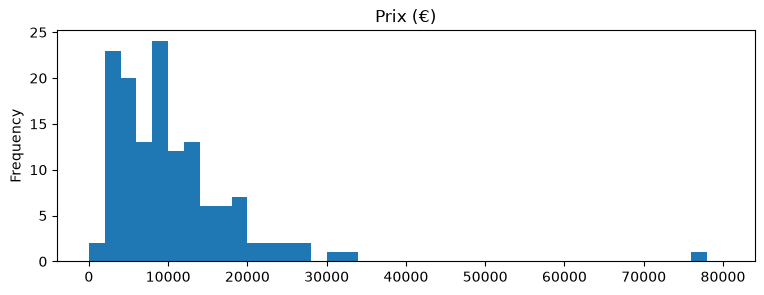

In [17]:
ventes["prix"].plot(kind="hist", bins=range(0, 80001, 2000), figsize=(9, 3), title="Prix (€)");

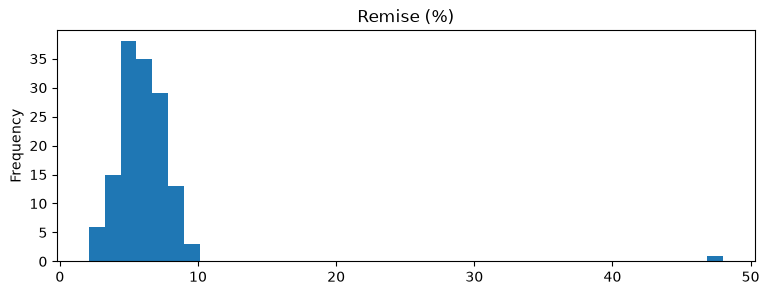

In [18]:
ventes["remise"].plot(kind="hist", bins=40, figsize=(9, 3), title="Remise (%)");

Deux formes très différentes :

- le **prix** a une longue queue à droite : beaucoup de voitures bon marché, quelques chères ;
- la **remise** fait une cloche autour de 6 %, à part un point isolé, très loin, à droite.

Sur une distribution avec une longue queue, la moyenne est tirée vers la queue. La médiane,
non :

In [19]:
print("Prix moyen  :", round(ventes["prix"].mean()), "€")
print("Prix médian :", ventes["prix"].median(), "€")

Prix moyen  : 10412 €
Prix médian : 8700.0 €


## 6. Les valeurs aberrantes

### Méthode 1 : le z-score, pour une distribution en cloche

Le z-score dit à combien d'**écarts-types** une valeur est de la moyenne. Au-delà de 3, c'est
très rare dans une cloche : 3 valeurs sur 1 000. On l'utilise sur la **remise**, qui a la forme
d'une cloche.

`std(ddof=0)` : on divise par le nombre de valeurs, comme au tableau.

In [20]:
moyenne = ventes["remise"].mean()
ecart_type = ventes["remise"].std(ddof=0)
z = (ventes["remise"] - moyenne) / ecart_type

ventes[z.abs() > 3]

,ref,agence,marque,modele,annee,kilometrage,carburant,etat,remise,prix
16,V-0016,Montbéliard,Dacia,Sandero,2019,66355.0,Essence,Correct,48.0,4800.0


Une seule ligne : la remise de 48 %. La virgule de 4,8 a sauté.

### Méthode 2 : les quartiles, qui ne supposent aucune forme

On range les prix, on coupe en quatre. Entre le premier quartile (Q1) et le troisième (Q3), il
y a la moitié des voitures : c'est l'**écart interquartile** (IQR). Tout ce qui dépasse Q3 de
plus d'une fois et demie cet écart est signalé.

In [21]:
q1 = ventes["prix"].quantile(0.25)
q3 = ventes["prix"].quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr
print("Q1 =", q1, " Q3 =", q3, " IQR =", iqr)
print("bornes :", borne_basse, "et", borne_haute)

ventes[(ventes["prix"] < borne_basse) | (ventes["prix"] > borne_haute)]

Q1 = 4900.0  Q3 = 13000.0  IQR = 8100.0
bornes : -7250.0 et 25150.0


,ref,agence,marque,modele,annee,kilometrage,carburant,etat,remise,prix
17,V-0017,Besançon,Peugeot,208,2019,61240.0,Essence,Bon,7.1,77000.0
23,V-0023,Besançon,Toyota,C-HR,2024,21321.0,Hybride,Bon,7.6,26000.0
63,V-0063,Belfort,Toyota,C-HR,2024,24921.0,Hybride,Bon,5.5,26700.0
89,V-0087,Montbéliard,Peugeot,3008,2024,11231.0,Hybride,Très bon,5.9,32000.0
134,V-0129,Besançon,Peugeot,3008,2024,4050.0,Diesel,Bon,5.2,30900.0


Cinq voitures signalées. Le 77 000 € est une erreur. Les quatre autres sont des voitures
**chères, mais vraies** : c'est la longue queue de la distribution. **Détecter n'est pas
supprimer** : on regarde chaque ligne avant de décider.

Et les deux prix à 1 € ? Aucune des deux méthodes ne les voit. Il faut une **borne fixée avec
le métier** : aucune voiture ne se vend moins de 1 000 €.

### La décision : on ne devine pas

On vide les cases impossibles. `mask` veut dire : « cache la valeur quand cette condition
est vraie ».

In [22]:
ventes["annee"] = ventes["annee"].mask(ventes["annee"] > 2025)
ventes["kilometrage"] = ventes["kilometrage"].mask(ventes["kilometrage"] > 500000)
ventes["prix"] = ventes["prix"].mask((ventes["prix"] < 1000) | (ventes["prix"] > 50000))
ventes["remise"] = ventes["remise"].mask(ventes["remise"] > 30)

## 7. Les cases vides

Combien de cases vides, colonne par colonne ?

In [23]:
ventes.isna().sum()

ref            0
agence         0
marque         0
modele         0
annee          1
kilometrage    9
carburant      5
etat           0
remise         1
prix           6
dtype: int64

Une décision par colonne, comme en cours :

| Colonne | Décision | Pourquoi |
|---|---|---|
| `prix` | supprimer la ligne | c'est la cible : sans elle, la ligne ne sert à rien |
| `annee` | supprimer la ligne | une seule ligne concernée |
| `kilometrage` | remplir avec la **médiane** | la distribution a une longue queue : la moyenne serait tirée vers le haut |
| `remise` | remplir avec la médiane | une seule case |
| `carburant` | écrire « Inconnu » | on garde la ligne, sans inventer de carburant |

In [24]:
ventes = ventes.dropna(subset=["prix", "annee"])
ventes["annee"] = ventes["annee"].astype(int)

ventes["kilometrage"] = ventes["kilometrage"].fillna(ventes["kilometrage"].median())
ventes["remise"] = ventes["remise"].fillna(ventes["remise"].median())
ventes["carburant"] = ventes["carburant"].fillna("Inconnu")

ventes.isna().sum()

ref            0
agence         0
marque         0
modele         0
annee          0
kilometrage    0
carburant      0
etat           0
remise         0
prix           0
dtype: int64

### La réponse à Nathalie : combien de ventes utilisables ?

In [25]:
len(ventes)

133

## 8. La corrélation : deux colonnes ensemble

`corr()` calcule le coefficient r pour chaque paire de colonnes. La diagonale vaut 1 : une
colonne est parfaitement corrélée avec elle-même.

In [26]:
ventes[["annee", "kilometrage", "remise", "prix"]].corr().round(2)

,annee,kilometrage,remise,prix
annee,1.00,-0.83,-0.00,0.82
kilometrage,-0.83,1.00,0.14,-0.74
remise,-0.00,0.14,1.00,0.02
prix,0.82,-0.74,0.02,1.00


L'année et le kilométrage sont liés (−0,83) : une voiture récente a peu roulé. Le nuage de
points le montre. Chaque point est une voiture.

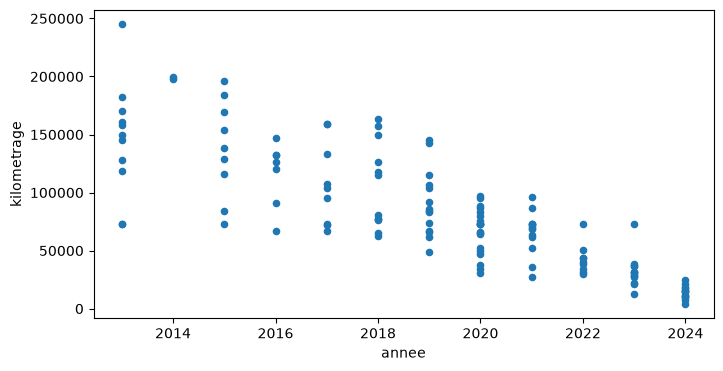

In [27]:
ventes.plot(kind="scatter", x="annee", y="kilometrage", figsize=(8, 4));

**Deux colonnes jumelles.** Ajoutons une colonne `age`, l'âge de la voiture en 2025. Elle ne dit
rien de plus que l'année :

In [28]:
ventes["age"] = 2025 - ventes["annee"]
ventes[["annee", "age"]].corr()

,annee,age
annee,1.0,-1.0
age,-1.0,1.0


r = −1 : la même information, dans l'autre sens. On n'en garde qu'une.

In [29]:
ventes = ventes.drop(columns=["age"])
list(ventes.columns)

['ref',
 'agence',
 'marque',
 'modele',
 'annee',
 'kilometrage',
 'carburant',
 'etat',
 'remise',
 'prix']

## 9. Le texte que la machine ne sait pas lire

### L'état a un ordre : encodage ordinal

Mauvais < Correct < Bon < Très bon. Des nombres qui respectent cet ordre disent la vérité.

In [30]:
ordre_etat = {"Mauvais": 0, "Correct": 1, "Bon": 2, "Très bon": 3}
ventes["etat_code"] = ventes["etat"].map(ordre_etat)

ventes.groupby("etat_code")["prix"].median()

etat_code
0     3500.0
1     6700.0
2     9450.0
3    12400.0
Name: prix, dtype: float64

Plus l'état est bon, plus le prix médian monte : l'ordre porte une information, la machine
pourra s'en servir.

### Le carburant n'a pas d'ordre : encodage one-hot

Une colonne par carburant, avec 1 ou 0. Aucune fausse hiérarchie.

In [31]:
pd.get_dummies(ventes["carburant"], prefix="carburant", dtype=int).head(8)

,carburant_Diesel,carburant_Essence,carburant_Hybride,carburant_Inconnu,carburant_Électrique
0,1,0,0,0,0
1,1,0,0,0,0
2,0,1,0,0,0
3,1,0,0,0,0
5,0,1,0,0,0
6,0,1,0,0,0
7,0,0,1,0,0
9,1,0,0,0,0


## 10. La même échelle pour tous

**Normalisation** : ramener entre 0 (le plus petit) et 1 (le plus grand).

**Standardisation** : moyenne 0, écart-type 1. Chaque valeur devient son z-score.

In [32]:
km = ventes["kilometrage"]
ventes["km_normalise"] = (km - km.min()) / (km.max() - km.min())
ventes["km_standardise"] = (km - km.mean()) / km.std(ddof=0)

ventes[["kilometrage", "km_normalise", "km_standardise"]].describe().round(2)

,kilometrage,km_normalise,km_standardise
count,133.00,133.00,133.00
mean,80990.97,0.32,-0.00
std,50472.84,0.21,1.00
min,4050.00,0.00,-1.53
25%,38049.00,0.14,-0.85
50%,72736.00,0.28,-0.16
75%,114982.00,0.46,0.68
max,245277.00,1.00,3.27


Après normalisation : minimum 0, maximum 1. Après standardisation : moyenne 0, écart-type 1,
et pas de bornes.

**Les mêmes gestes existent dans scikit-learn**, la bibliothèque de machine learning que nous
utiliserons dans ce cours :

In [33]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

colonnes = ["annee", "kilometrage", "remise"]
normalise = MinMaxScaler().fit_transform(ventes[colonnes])
standardise = StandardScaler().fit_transform(ventes[colonnes])

print("normalisé, 3 premières lignes :")
print(normalise[:3].round(2))
print("standardisé, 3 premières lignes :")
print(standardise[:3].round(2))

normalisé, 3 premières lignes :
[[0.73 0.38 0.38]
 [0.82 0.11 0.64]
 [0.   0.59 0.56]]
standardisé, 3 premières lignes :
[[ 0.54  0.31 -0.59]
 [ 0.85 -1.01  0.72]
 [-1.92  1.28  0.33]]


## Enregistrer le fichier propre

In [34]:
ventes.to_excel("donnees/ventes-propres.xlsx", index=False)
print("Fichier propre enregistré : donnees/ventes-propres.xlsx")

Fichier propre enregistré : donnees/ventes-propres.xlsx
